In [2]:
# Install karo
!pip install rdkit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 48.3 MB/s eta 0:00:00


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Descriptors

# 10 drugs
drugs = {
    'Aspirin':     'CC(=O)Oc1ccccc1C(=O)O',
    'Caffeine':    'Cn1cnc2c1c(=O)n(C)c(=O)n2C',
    'Ibuprofen':   'CC(C)Cc1ccc(C(C)C(=O)O)cc1',
    'Paracetamol': 'CC(=O)Nc1ccc(O)cc1',
    'Penicillin':  'CC1(C)SC2C(NC(=O)Cc3ccccc3)C(=O)N2C1C(=O)O',
    'Morphine':    'CN1CCC23c4c5ccc(O)c4OC2C(O)C=CC3C1C5',
    'Glucose':     'OCC(O)C(O)C(O)C(O)C=O',
    'Nicotine':    'CN1CCCC1c1cccnc1',
    'Cocaine':     'COC(=O)C1C(OC(=O)c2ccccc2)CC2CCC1N2C',
    'UDS1b':       'C1=CC=CC=C1C(C[Se]C(C2=CC=CC=C2)=O)=O'
}

data = []
for name, smiles in drugs.items():
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        data.append({
            'Name': name,
            'MW': round(Descriptors.MolWt(mol), 2),
            'LogP': round(Descriptors.MolLogP(mol), 2),
            'TPSA': round(Descriptors.TPSA(mol), 2)
        })

df = pd.DataFrame(data)
print("✅ Data ready!")
df

✅ Data ready!


,Name,MW,LogP,TPSA
0,Aspirin,180.16,1.31,63.60
1,Caffeine,194.19,-1.03,61.82
2,Ibuprofen,206.28,3.07,37.30
3,Paracetamol,151.16,1.35,49.33
4,Penicillin,334.40,0.86,86.71
5,Morphine,285.34,1.20,52.93
6,Glucose,180.16,-3.38,118.22
7,Nicotine,162.24,1.85,16.13
8,Cocaine,303.36,1.87,55.84
9,UDS1b,303.22,2.83,34.14


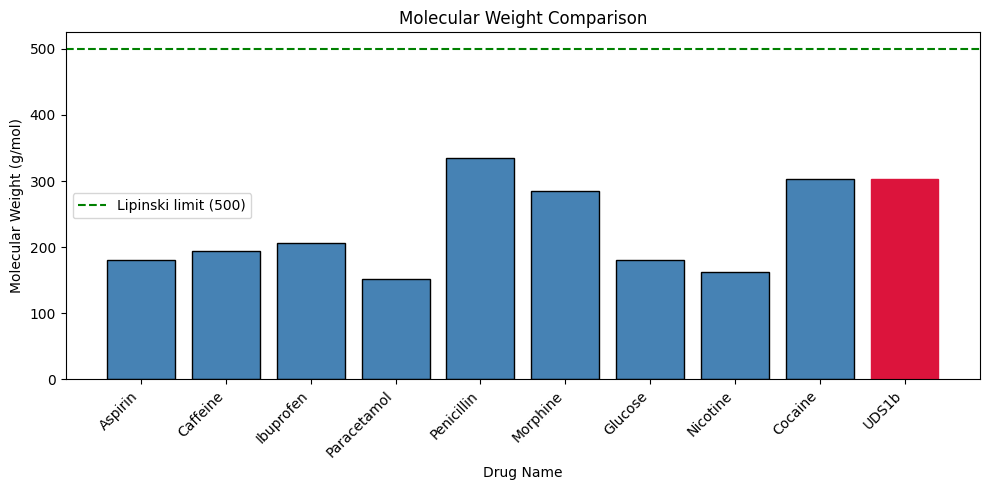

In [4]:
import matplotlib.pyplot as plt

# Bar plot
plt.figure(figsize=(10, 5))
bars = plt.bar(df['Name'], df['MW'], color='steelblue', edgecolor='black')

# UDS1b ko highlight karo
uds1b_index = df[df['Name'] == 'UDS1b'].index[0]
bars[uds1b_index].set_color('crimson')

plt.xlabel('Drug Name')
plt.ylabel('Molecular Weight (g/mol)')
plt.title('Molecular Weight Comparison')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=500, color='green', linestyle='--', label='Lipinski limit (500)')
plt.legend()
plt.tight_layout()
plt.show()

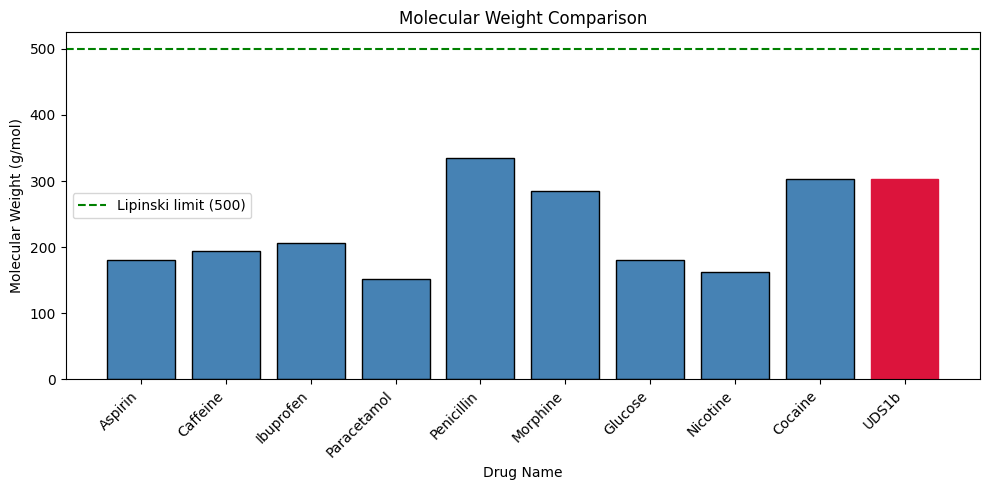

✅ Image saved!


In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
bars = plt.bar(df['Name'], df['MW'], color='steelblue', edgecolor='black')

uds1b_index = df[df['Name'] == 'UDS1b'].index[0]
bars[uds1b_index].set_color('crimson')

plt.xlabel('Drug Name')
plt.ylabel('Molecular Weight (g/mol)')
plt.title('Molecular Weight Comparison')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=500, color='green', linestyle='--', label='Lipinski limit (500)')
plt.legend()
plt.tight_layout()

# ⭐ Yeh line add ki
plt.savefig('molecular_weight_comparison.png', dpi=300, bbox_inches='tight')

plt.show()
print("✅ Image saved!")

In [6]:
# File save hone ke baad
from google.colab import files
files.download('molecular_weight_comparison.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

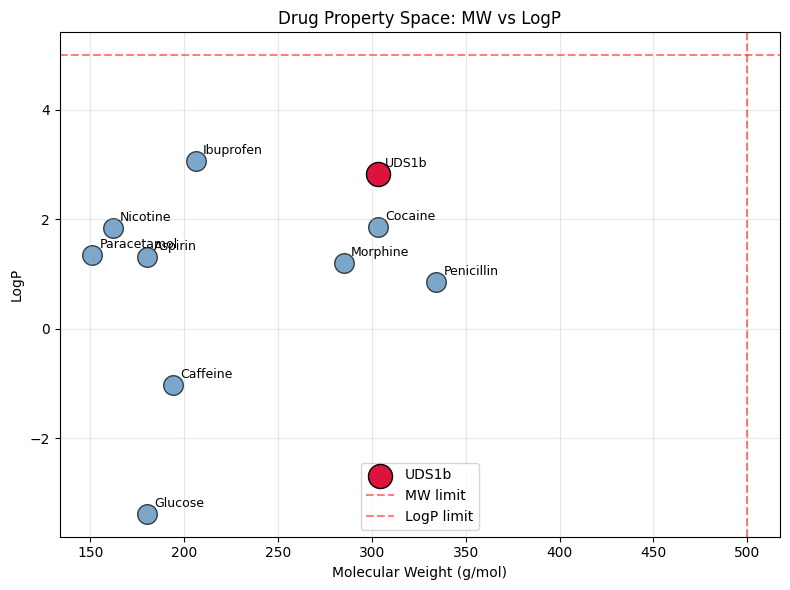

In [7]:
plt.figure(figsize=(8, 6))

# Scatter plot - MW vs LogP
plt.scatter(df['MW'], df['LogP'],
            s=200, color='steelblue',
            edgecolor='black', alpha=0.7)

# UDS1b ko highlight
uds1b = df[df['Name'] == 'UDS1b'].iloc[0]
plt.scatter(uds1b['MW'], uds1b['LogP'],
            s=300, color='crimson',
            edgecolor='black', label='UDS1b', zorder=5)

# Drug names label karo
for i, row in df.iterrows():
    plt.annotate(row['Name'],
                 (row['MW'], row['LogP']),
                 xytext=(5, 5), textcoords='offset points',
                 fontsize=9)

plt.xlabel('Molecular Weight (g/mol)')
plt.ylabel('LogP')
plt.title('Drug Property Space: MW vs LogP')
plt.axvline(x=500, color='red', linestyle='--', alpha=0.5, label='MW limit')
plt.axhline(y=5, color='red', linestyle='--', alpha=0.5, label='LogP limit')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('drug_property_space.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
from google.colab import files
files.download('drug_property_space.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>